CT shape: (512, 512, 461)
GT mask shape: (1, 512, 512, 461)
GT labels: [0. 1. 2. 3.]
Using GT mask shape: (512, 512, 461)
Displaying slice: 333

Voxel counts
CT total voxels        : 120848384
Mask total voxels      : 120848384
Mask positive voxels   : 7253
Mask background voxels : 120841131
Mask percentage of CT  : 0.006002%


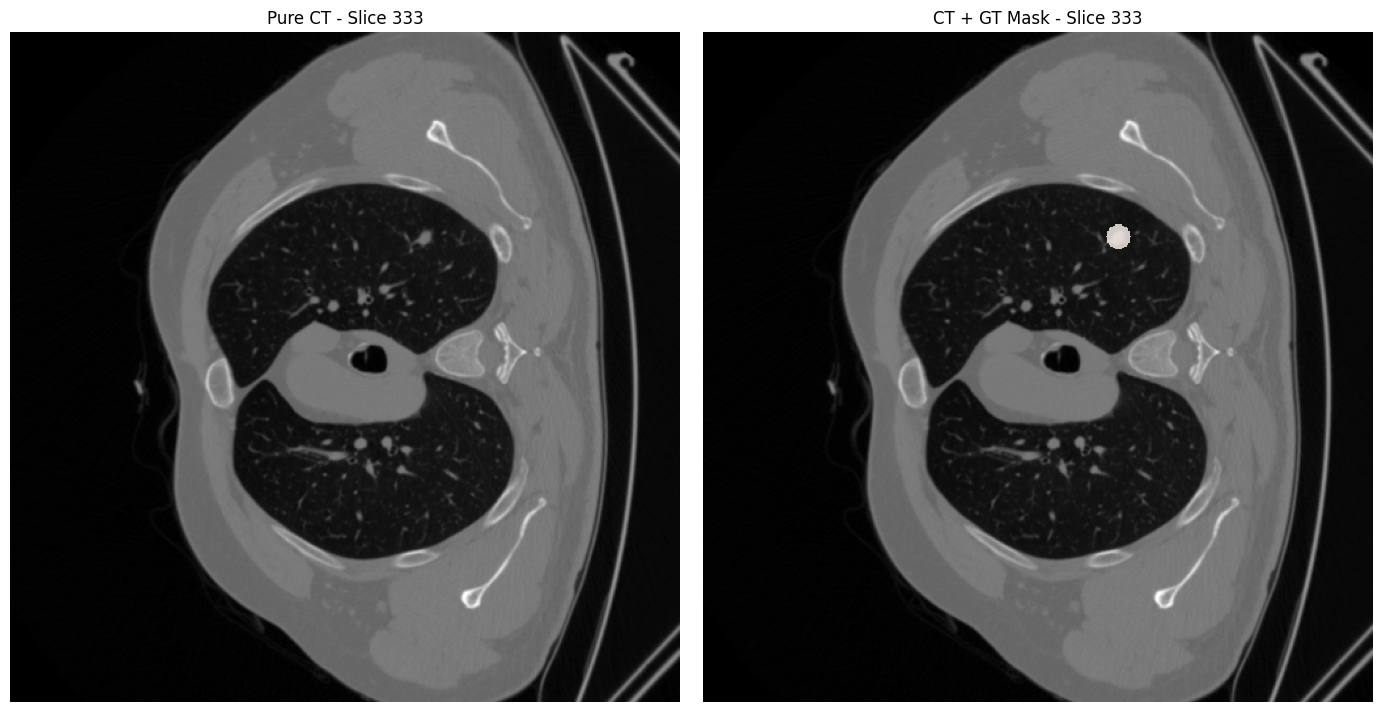

In [ ]:
import nibabel as nib
import numpy as np
import matplotlib.pyplot as plt


# -----------------------------
# Load NIfTI files
# -----------------------------

volume_path = r"/home/chest_ct/code/data/data_volumes/dataset/train_fixed/train_1387_a_2.nii.gz"

mask_path = r"/home/chest_ct/code/data/segmentations/segmentations/train_1387_a_2.nii.gz"


ct = nib.load(volume_path).get_fdata()
gt_mask = nib.load(mask_path).get_fdata()


print("CT shape:", ct.shape)
print("GT mask shape:", gt_mask.shape)
print("GT labels:", np.unique(gt_mask)[:20])


# -----------------------------
# Handle mask dimensions
# -----------------------------

if gt_mask.ndim == 4:
    finding = 0
    gt_mask = gt_mask[finding]

print("Using GT mask shape:", gt_mask.shape)


# -----------------------------
# Find slice with most nodule
# -----------------------------

slice_idx = np.argmax(
    (gt_mask > 0).sum(axis=(0, 1))
)

print("Displaying slice:", slice_idx)

# -----------------------------
# Voxel counts
# -----------------------------

ct_voxels = ct.size
mask_voxels = gt_mask.size

positive_mask_voxels = np.count_nonzero(gt_mask > 0)
zero_mask_voxels = mask_voxels - positive_mask_voxels

mask_percentage_of_volume = (positive_mask_voxels / ct_voxels) * 100

print("\nVoxel counts")
print("CT total voxels        :", ct_voxels)
print("Mask total voxels      :", mask_voxels)
print("Mask positive voxels   :", positive_mask_voxels)
print("Mask background voxels :", zero_mask_voxels)
print(f"Mask percentage of CT  : {mask_percentage_of_volume:.6f}%")


# -----------------------------
# Plot volume + overlay
# -----------------------------

fig, axes = plt.subplots(1, 2, figsize=(14, 7))


# Pure CT volume
axes[0].imshow(
    ct[:, :, slice_idx],
    cmap="gray"
)

axes[0].set_title(f"Pure CT - Slice {slice_idx}")
axes[0].axis("off")


# CT + GT mask overlay
axes[1].imshow(
    ct[:, :, slice_idx],
    cmap="gray"
)

seg = gt_mask[:, :, slice_idx]

axes[1].imshow(
    np.ma.masked_where(
        seg <= 0,
        seg
    ),
    cmap="Reds",
    alpha=0.8,
    interpolation="none"
)

axes[1].set_title(f"CT + GT Mask - Slice {slice_idx}")
axes[1].axis("off")


plt.tight_layout()
plt.show()

Using GT mask shape: (512, 512, 461)
Displaying slice: 333
GT pixels on slice: 269


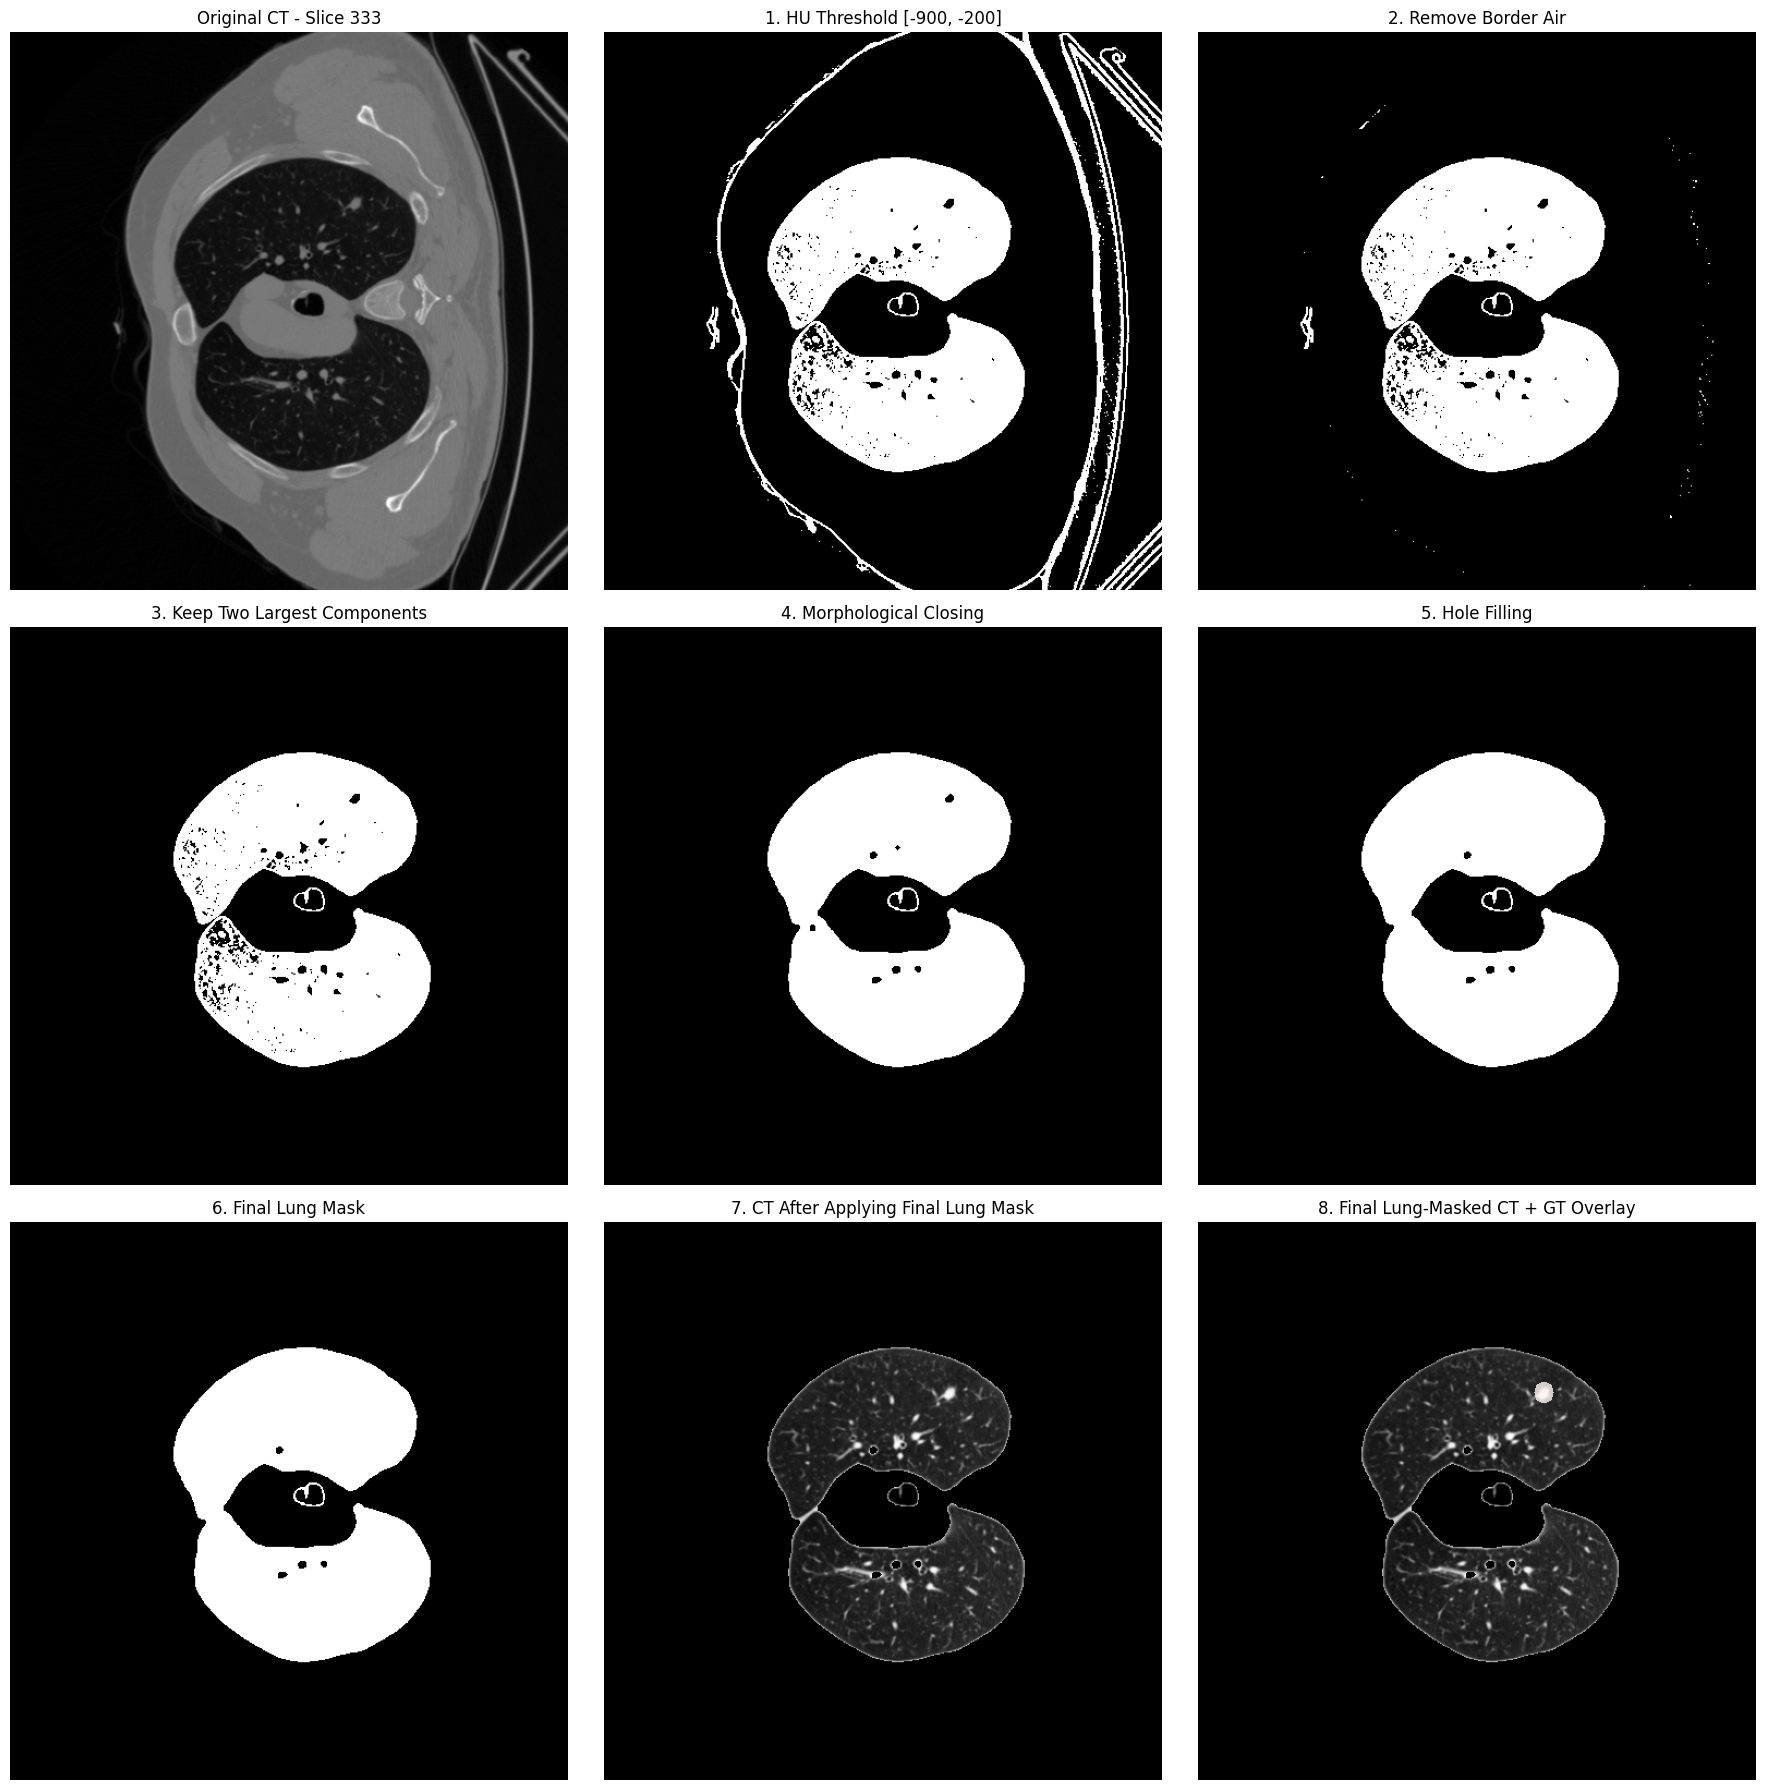

Voxel counts:
HU threshold mask: 18092982
After clear_border: 12163465
After largest components: 11903234
After closing: 12408121
After hole filling: 12544165
Final lung mask: 12544165
GT mask: 7253


In [3]:
import nibabel as nib
import numpy as np
import matplotlib.pyplot as plt

from scipy import ndimage
from skimage.segmentation import clear_border
from skimage.measure import label


# -----------------------------
# Helper: keep largest components
# -----------------------------
def keep_largest_components(binary_mask, n=2):
    """
    Keep the n largest connected components from a 3D binary mask.
    """
    labeled, num = label(binary_mask, return_num=True, connectivity=1)

    if num == 0:
        return np.zeros_like(binary_mask, dtype=bool)

    component_sizes = np.bincount(labeled.ravel())
    component_sizes[0] = 0  # ignore background

    largest_labels = np.argsort(component_sizes)[-n:]

    return np.isin(labeled, largest_labels)

# -----------------------------
# Handle GT mask dimensions
# -----------------------------
if gt_mask.ndim == 4:
    finding = 0
    gt_mask = gt_mask[finding]

print("Using GT mask shape:", gt_mask.shape)


# -----------------------------
# Find slice with most GT mask pixels
# -----------------------------
slice_idx = int(np.argmax((gt_mask > 0).sum(axis=(0, 1))))

print("Displaying slice:", slice_idx)
print("GT pixels on slice:", int((gt_mask[:, :, slice_idx] > 0).sum()))


# ============================================================
# Lung preprocessing pipeline
# ============================================================

# -----------------------------
# 1. HU threshold
# -----------------------------
lung_candidate = (ct >= -900) & (ct <= -200)


# -----------------------------
# 2. Remove border air slice-by-slice
# -----------------------------
mask_clear = np.zeros_like(lung_candidate, dtype=bool)

for k in range(lung_candidate.shape[2]):
    mask_clear[:, :, k] = clear_border(lung_candidate[:, :, k])


# -----------------------------
# 3. Keep two largest 3D components
# -----------------------------
lungs_only = keep_largest_components(mask_clear, n=2)


# -----------------------------
# 4. Morphological closing
# -----------------------------
structure = ndimage.generate_binary_structure(3, 2)

mask_closed = ndimage.binary_closing(
    lungs_only,
    structure=structure,
    iterations=2
)


# -----------------------------
# 5. Hole filling
# -----------------------------
mask_filled = ndimage.binary_fill_holes(mask_closed)


# -----------------------------
# 6. Final cleanup
# -----------------------------
lungs_final = ndimage.binary_closing(
    mask_filled,
    structure=structure,
    iterations=2
)

lungs_final = ndimage.binary_fill_holes(lungs_final)


# -----------------------------
# Apply final lung mask to CT
# -----------------------------
# Outside-lung voxels are set to a very dark HU value.
ct_lung_only = ct.copy()
ct_lung_only[~lungs_final] = -1000


# ============================================================
# Visualization
# ============================================================

ct_slice = ct[:, :, slice_idx]
gt_slice = gt_mask[:, :, slice_idx]
lung_candidate_slice = lung_candidate[:, :, slice_idx]
mask_clear_slice = mask_clear[:, :, slice_idx]
lungs_only_slice = lungs_only[:, :, slice_idx]
mask_closed_slice = mask_closed[:, :, slice_idx]
mask_filled_slice = mask_filled[:, :, slice_idx]
lungs_final_slice = lungs_final[:, :, slice_idx]
ct_lung_only_slice = ct_lung_only[:, :, slice_idx]


fig, axes = plt.subplots(3, 3, figsize=(18, 18))
axes = axes.ravel()

# 0. Original CT
axes[0].imshow(ct_slice, cmap="gray")
axes[0].set_title(f"Original CT - Slice {slice_idx}")
axes[0].axis("off")

# 1. HU threshold mask
axes[1].imshow(lung_candidate_slice, cmap="gray")
axes[1].set_title("1. HU Threshold [-900, -200]")
axes[1].axis("off")

# 2. Clear border
axes[2].imshow(mask_clear_slice, cmap="gray")
axes[2].set_title("2. Remove Border Air")
axes[2].axis("off")

# 3. Keep largest components
axes[3].imshow(lungs_only_slice, cmap="gray")
axes[3].set_title("3. Keep Two Largest Components")
axes[3].axis("off")

# 4. Closing
axes[4].imshow(mask_closed_slice, cmap="gray")
axes[4].set_title("4. Morphological Closing")
axes[4].axis("off")

# 5. Hole filling
axes[5].imshow(mask_filled_slice, cmap="gray")
axes[5].set_title("5. Hole Filling")
axes[5].axis("off")

# 6. Final lung mask
axes[6].imshow(lungs_final_slice, cmap="gray")
axes[6].set_title("6. Final Lung Mask")
axes[6].axis("off")

# 7. CT after applying lung mask
axes[7].imshow(ct_lung_only_slice, cmap="gray")
axes[7].set_title("7. CT After Applying Final Lung Mask")
axes[7].axis("off")

# 8. Final CT + GT overlay
axes[8].imshow(ct_lung_only_slice, cmap="gray")

axes[8].imshow(
    np.ma.masked_where(gt_slice <= 0, gt_slice),
    cmap="Reds",
    alpha=0.8,
    interpolation="none"
)

axes[8].set_title("8. Final Lung-Masked CT + GT Overlay")
axes[8].axis("off")

plt.tight_layout()
plt.show()


# ============================================================
# Optional: print voxel counts
# ============================================================
print("Voxel counts:")
print("HU threshold mask:", int(lung_candidate.sum()))
print("After clear_border:", int(mask_clear.sum()))
print("After largest components:", int(lungs_only.sum()))
print("After closing:", int(mask_closed.sum()))
print("After hole filling:", int(mask_filled.sum()))
print("Final lung mask:", int(lungs_final.sum()))
print("GT mask:", int((gt_mask > 0).sum()))

Using GT mask shape: (512, 512, 461)
Displaying slice: 333
GT pixels on slice: 269


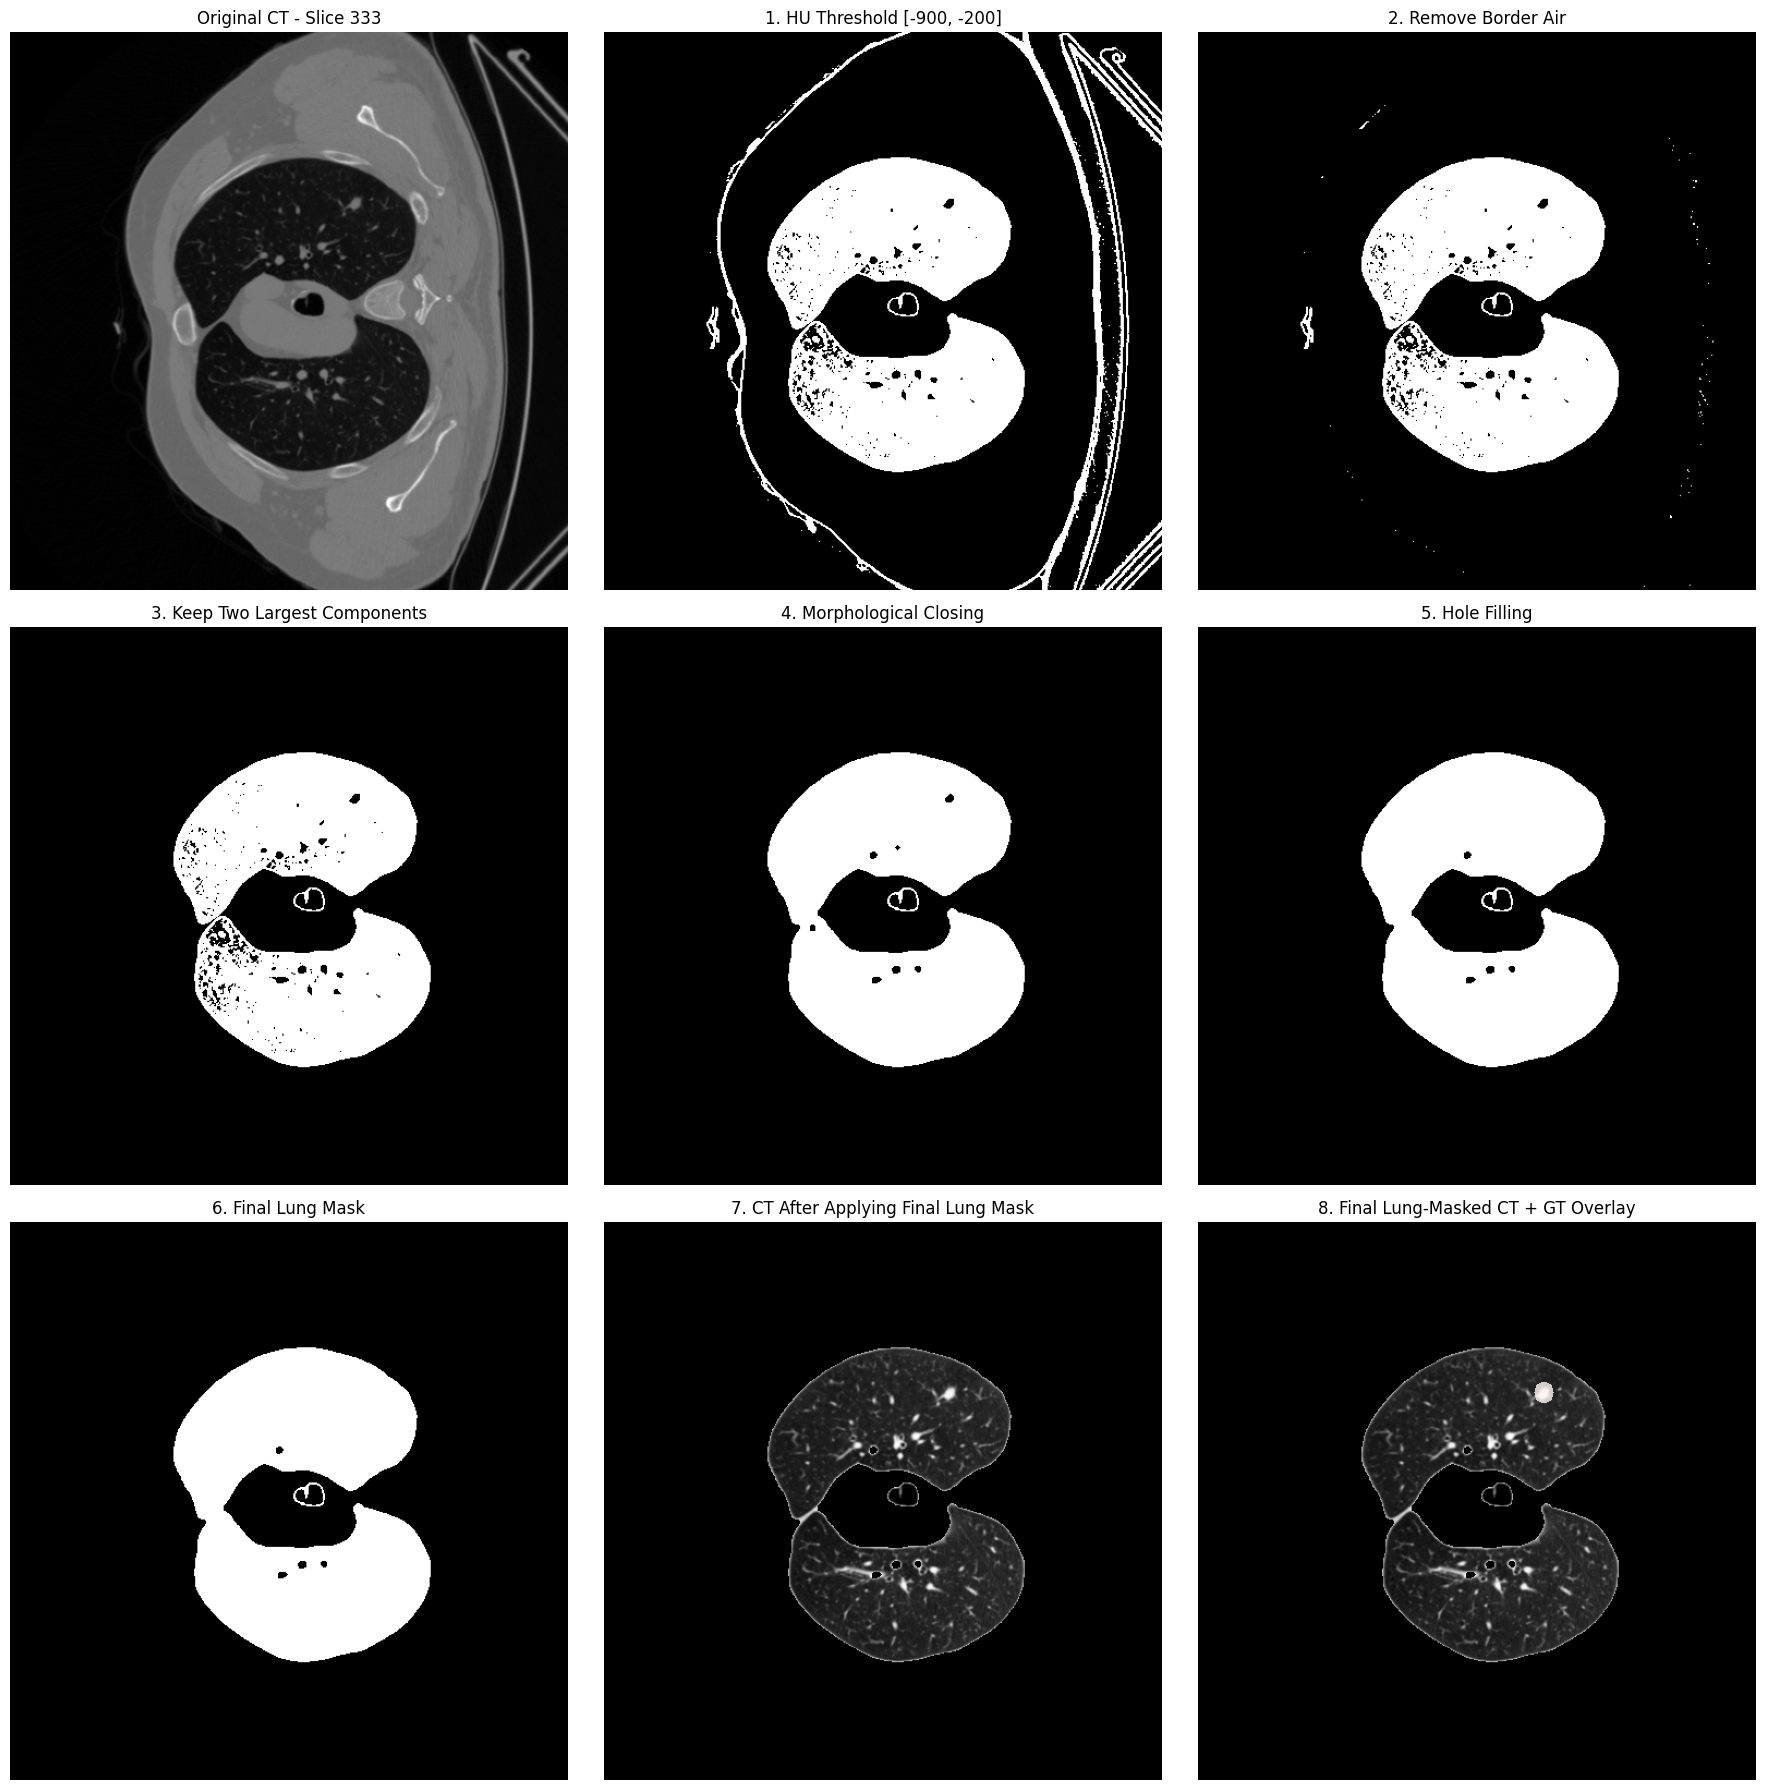

Voxel counts:
HU threshold mask: 18092982
After clear_border: 12163465
After largest components: 11903234
After closing: 12408121
After hole filling: 12544165
Final lung mask: 12544165
GT mask: 7253


In [39]:
import nibabel as nib
import numpy as np
import matplotlib.pyplot as plt

from scipy import ndimage
from skimage.segmentation import clear_border
from skimage.measure import label


# -----------------------------
# Helper: keep largest components
# -----------------------------
def keep_largest_components(binary_mask, n=2):
    """
    Keep the n largest connected components from a 3D binary mask.
    """
    labeled, num = label(binary_mask, return_num=True, connectivity=1)

    if num == 0:
        return np.zeros_like(binary_mask, dtype=bool)

    component_sizes = np.bincount(labeled.ravel())
    component_sizes[0] = 0  # ignore background

    largest_labels = np.argsort(component_sizes)[-n:]

    return np.isin(labeled, largest_labels)

# -----------------------------
# Handle GT mask dimensions
# -----------------------------
if gt_mask.ndim == 4:
    finding = 0
    gt_mask = gt_mask[finding]

print("Using GT mask shape:", gt_mask.shape)


# -----------------------------
# Find slice with most GT mask pixels
# -----------------------------
slice_idx = int(np.argmax((gt_mask > 0).sum(axis=(0, 1))))

print("Displaying slice:", slice_idx)
print("GT pixels on slice:", int((gt_mask[:, :, slice_idx] > 0).sum()))


# ============================================================
# Lung preprocessing pipeline
# ============================================================

# -----------------------------
# 1. HU threshold
# -----------------------------
lung_candidate = (ct >= -900) & (ct <= -200)


# -----------------------------
# 2. Remove border air slice-by-slice
# -----------------------------
mask_clear = np.zeros_like(lung_candidate, dtype=bool)

for k in range(lung_candidate.shape[2]):
    mask_clear[:, :, k] = clear_border(lung_candidate[:, :, k])


# -----------------------------
# 3. Keep two largest 3D components
# -----------------------------
lungs_only = keep_largest_components(mask_clear, n=2)


# -----------------------------
# 4. Morphological closing
# -----------------------------
structure = ndimage.generate_binary_structure(3, 2)

mask_closed = ndimage.binary_closing(
    lungs_only,
    structure=structure,
    iterations=2
)


# -----------------------------
# 5. Hole filling
# -----------------------------
mask_filled = ndimage.binary_fill_holes(mask_closed)


# -----------------------------
# 6. Final cleanup
# -----------------------------
lungs_final = ndimage.binary_closing(
    mask_filled,
    structure=structure,
    iterations=2
)

lungs_final = ndimage.binary_fill_holes(lungs_final)


# -----------------------------
# Apply final lung mask to CT
# -----------------------------
# Outside-lung voxels are set to a very dark HU value.
ct_lung_only = ct.copy()
ct_lung_only[~lungs_final] = -1000


# ============================================================
# Visualization
# ============================================================

ct_slice = ct[:, :, slice_idx]
gt_slice = gt_mask[:, :, slice_idx]
lung_candidate_slice = lung_candidate[:, :, slice_idx]
mask_clear_slice = mask_clear[:, :, slice_idx]
lungs_only_slice = lungs_only[:, :, slice_idx]
mask_closed_slice = mask_closed[:, :, slice_idx]
mask_filled_slice = mask_filled[:, :, slice_idx]
lungs_final_slice = lungs_final[:, :, slice_idx]
ct_lung_only_slice = ct_lung_only[:, :, slice_idx]


fig, axes = plt.subplots(3, 3, figsize=(18, 18))
axes = axes.ravel()

# 0. Original CT
axes[0].imshow(ct_slice, cmap="gray")
axes[0].set_title(f"Original CT - Slice {slice_idx}")
axes[0].axis("off")

# 1. HU threshold mask
axes[1].imshow(lung_candidate_slice, cmap="gray")
axes[1].set_title("1. HU Threshold [-900, -200]")
axes[1].axis("off")

# 2. Clear border
axes[2].imshow(mask_clear_slice, cmap="gray")
axes[2].set_title("2. Remove Border Air")
axes[2].axis("off")

# 3. Keep largest components
axes[3].imshow(lungs_only_slice, cmap="gray")
axes[3].set_title("3. Keep Two Largest Components")
axes[3].axis("off")

# 4. Closing
axes[4].imshow(mask_closed_slice, cmap="gray")
axes[4].set_title("4. Morphological Closing")
axes[4].axis("off")

# 5. Hole filling
axes[5].imshow(mask_filled_slice, cmap="gray")
axes[5].set_title("5. Hole Filling")
axes[5].axis("off")

# 6. Final lung mask
axes[6].imshow(lungs_final_slice, cmap="gray")
axes[6].set_title("6. Final Lung Mask")
axes[6].axis("off")

# 7. CT after applying lung mask
axes[7].imshow(ct_lung_only_slice, cmap="gray")
axes[7].set_title("7. CT After Applying Final Lung Mask")
axes[7].axis("off")

# 8. Final CT + GT overlay
axes[8].imshow(ct_lung_only_slice, cmap="gray")

axes[8].imshow(
    np.ma.masked_where(gt_slice <= 0, gt_slice),
    cmap="Reds",
    alpha=0.8,
    interpolation="none"
)

axes[8].set_title("8. Final Lung-Masked CT + GT Overlay")
axes[8].axis("off")

plt.tight_layout()
plt.show()


# ============================================================
# Optional: print voxel counts
# ============================================================
print("Voxel counts:")
print("HU threshold mask:", int(lung_candidate.sum()))
print("After clear_border:", int(mask_clear.sum()))
print("After largest components:", int(lungs_only.sum()))
print("After closing:", int(mask_closed.sum()))
print("After hole filling:", int(mask_filled.sum()))
print("Final lung mask:", int(lungs_final.sum()))
print("GT mask:", int((gt_mask > 0).sum()))

Number of GT voxels: 7253

HU distribution inside GT mask
Min : -903.0
P1  : -864.0
P5  : -837.0
P25 : -765.0
P50 : -616.0
P75 : -232.0
P95 : 32.0
P99 : 55.0
Max : 78.0
Mean: -499.9619467806425
Median: -616.0
Std : 305.4109620077608


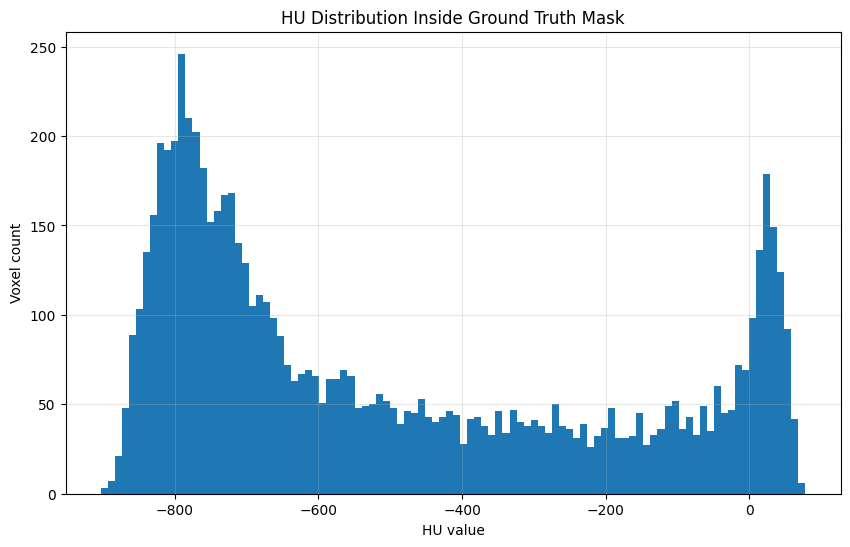

In [4]:
# ============================================================
# HU distribution inside GT mask
# ============================================================

# If GT mask is multi-channel, select one finding/channel
if gt_mask.ndim == 4:
    finding = 0
    gt_mask_single = gt_mask[finding]
else:
    gt_mask_single = gt_mask

# Convert GT to boolean mask
gt_bool = gt_mask_single > 0

# Extract HU values inside GT
gt_hu_values = ct[gt_bool]

# Remove NaN / inf if any
gt_hu_values = gt_hu_values[np.isfinite(gt_hu_values)]

print("Number of GT voxels:", gt_hu_values.size)

if gt_hu_values.size > 0:
    print("\nHU distribution inside GT mask")
    print("Min :", float(np.min(gt_hu_values)))
    print("P1  :", float(np.percentile(gt_hu_values, 1)))
    print("P5  :", float(np.percentile(gt_hu_values, 5)))
    print("P25 :", float(np.percentile(gt_hu_values, 25)))
    print("P50 :", float(np.percentile(gt_hu_values, 50)))  # median
    print("P75 :", float(np.percentile(gt_hu_values, 75)))
    print("P95 :", float(np.percentile(gt_hu_values, 95)))
    print("P99 :", float(np.percentile(gt_hu_values, 99)))
    print("Max :", float(np.max(gt_hu_values)))
    print("Mean:", float(np.mean(gt_hu_values)))
    print("Median:", float(np.median(gt_hu_values)))
    print("Std :", float(np.std(gt_hu_values)))

    # Plot histogram
    plt.figure(figsize=(10, 6))
    plt.hist(gt_hu_values, bins=100)
    plt.xlabel("HU value")
    plt.ylabel("Voxel count")
    plt.title("HU Distribution Inside Ground Truth Mask")
    plt.grid(alpha=0.3)
    plt.show()
else:
    print("GT mask is empty.")

Selected CTs: 543



Processed: 454
Missing CTs: 70
Missing masks: 19

Missing CT files:
  valid_1001_a_1.nii.gz
  valid_1055_a_1.nii.gz
  valid_1061_a_2.nii.gz
  valid_1077_a_2.nii.gz
  valid_1091_a_1.nii.gz
  valid_1102_a_2.nii.gz
  valid_1103_a_2.nii.gz
  valid_110_a_1.nii.gz
  valid_1113_a_2.nii.gz
  valid_1119_a_1.nii.gz
  valid_1141_a_2.nii.gz
  valid_114_b_2.nii.gz
  valid_1196_a_1.nii.gz
  valid_1213_a_1.nii.gz
  valid_1235_a_2.nii.gz
  valid_1261_a_2.nii.gz
  valid_147_a_2.nii.gz
  valid_189_a_1.nii.gz
  valid_1_a_2.nii.gz
  valid_280_a_2.nii.gz

Missing mask files:
  train_13000_a_2.nii.gz
  train_13011_a_2.nii.gz
  train_13014_a_2.nii.gz
  train_13025_a_2.nii.gz
  train_13043_a_1.nii.gz
  train_13097_b_2.nii.gz
  train_13125_a_2.nii.gz
  train_13218_b_2.nii.gz
  train_13278_c_1.nii.gz
  train_13365_a_2.nii.gz
  train_13380_a_1.nii.gz
  train_13423_a_2.nii.gz
  train_13459_a_2.nii.gz
  train_13484_a_2.nii.gz
  train_13490_a_1.nii.gz
  train_13521_a_1.nii.gz
  train_13593_b_2.nii.gz
  train_13604

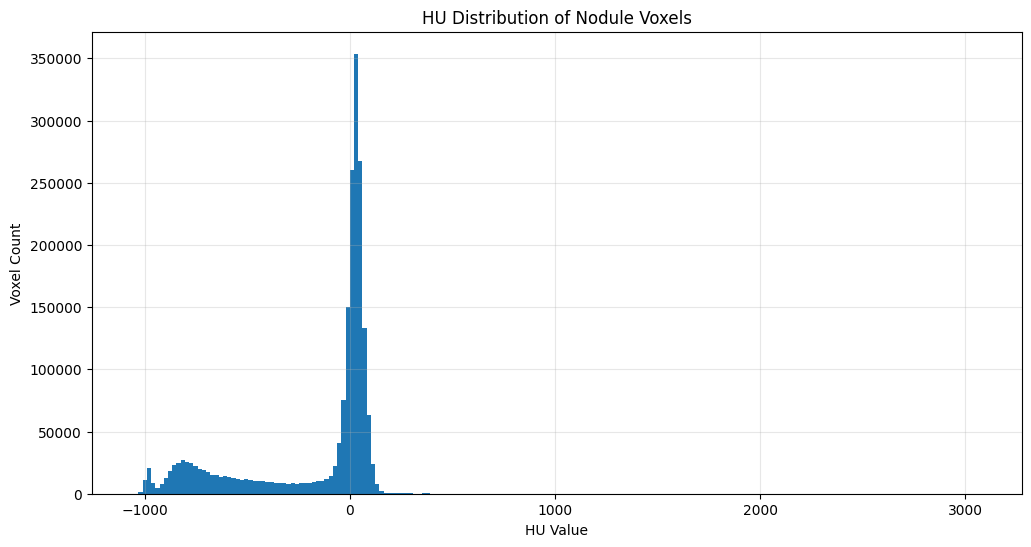

In [4]:
import os
import json
import nibabel as nib
import numpy as np
import matplotlib.pyplot as plt

# --------------------------------------------------
# Paths
# --------------------------------------------------

volume_dir = "/home/chest_ct/code/data/data_volumes/dataset/train_fixed"
mask_dir = "/home/chest_ct/code/data/segmentations/segmentations"

json_path = "/home/chest_ct/code/data/rexgrounding-ct/dataset_2d.json"

# --------------------------------------------------
# Load selected cases
# --------------------------------------------------

with open(json_path, "r") as f:
    dataset = json.load(f)

selected_files = set(
    dataset.get("train", []) +
    dataset.get("test", [])
)

print(f"Selected CTs: {len(selected_files)}")

# --------------------------------------------------
# Collect HU values
# --------------------------------------------------

all_hu_values = []

processed = 0
missing_ct = []
missing_mask = []

for filename in sorted(selected_files):

    volume_path = os.path.join(volume_dir, filename)
    mask_path = os.path.join(mask_dir, filename)

    if not os.path.exists(volume_path):
        missing_ct.append(filename)
        continue

    if not os.path.exists(mask_path):
        missing_mask.append(filename)
        continue

    try:
        ct = nib.load(volume_path).get_fdata()
        gt_mask = nib.load(mask_path).get_fdata()

        # Multi-channel mask -> union of channels
        if gt_mask.ndim == 4:
            gt_mask = np.any(gt_mask > 0, axis=0)
        else:
            gt_mask = gt_mask > 0

        hu_values = ct[gt_mask]
        hu_values = hu_values[np.isfinite(hu_values)]

        if hu_values.size > 0:
            all_hu_values.append(hu_values)

        processed += 1

    except Exception as e:
        print(f"Error processing {filename}: {e}")

# --------------------------------------------------
# Summary
# --------------------------------------------------

print(f"\nProcessed: {processed}")
print(f"Missing CTs: {len(missing_ct)}")
print(f"Missing masks: {len(missing_mask)}")

if missing_ct:
    print("\nMissing CT files:")
    for x in missing_ct[:20]:
        print(" ", x)

if missing_mask:
    print("\nMissing mask files:")
    for x in missing_mask[:20]:
        print(" ", x)

# --------------------------------------------------
# HU statistics
# --------------------------------------------------

all_hu_values = np.concatenate(all_hu_values)

print("\n========== GLOBAL NODULE HU STATS ==========")
print("Voxel count:", all_hu_values.size)

for p in [1, 5, 25, 50, 75, 95, 99]:
    print(f"P{p:<2}:", float(np.percentile(all_hu_values, p)))

print("Min   :", float(np.min(all_hu_values)))
print("Max   :", float(np.max(all_hu_values)))
print("Mean  :", float(np.mean(all_hu_values)))
print("Std   :", float(np.std(all_hu_values)))

# --------------------------------------------------
# Histogram
# --------------------------------------------------

plt.figure(figsize=(12, 6))
plt.hist(all_hu_values, bins=200)
plt.xlabel("HU Value")
plt.ylabel("Voxel Count")
plt.title("HU Distribution of Nodule Voxels")
plt.grid(alpha=0.3)
plt.show()

In [5]:
# ============================================================
# Narrowest HU ranges containing given percentages of GT values
# ============================================================

def narrowest_hu_range(values, percentages=[1, 5, 10, 15, 50]):
    values = np.asarray(values)
    values = values[np.isfinite(values)]
    values = np.sort(values)

    n = values.size

    if n == 0:
        print("No HU values found.")
        return {}

    results = {}

    for p in percentages:
        # Number of voxels needed to include p%
        window_size = max(1, int(np.ceil((p / 100) * n)))

        # Sliding window over sorted HU values
        starts = values[: n - window_size + 1]
        ends = values[window_size - 1 :]

        widths = ends - starts
        best_idx = int(np.argmin(widths))

        hu_min = float(starts[best_idx])
        hu_max = float(ends[best_idx])
        width = float(hu_max - hu_min)

        results[p] = {
            "min": hu_min,
            "max": hu_max,
            "width": width,
            "voxels": window_size,
        }

        print(f"{p}% HU range:")
        print(f"  Min HU : {hu_min:.2f}")
        print(f"  Max HU : {hu_max:.2f}")
        print(f"  Width  : {width:.2f}")
        print(f"  Voxels : {window_size}")
        print()

    return results


hu_ranges = narrowest_hu_range(gt_hu_values, percentages=[1, 5, 10, 25, 50])

1% HU range:
  Min HU : -832.00
  Max HU : -832.00
  Width  : 0.00
  Voxels : 5

5% HU range:
  Min HU : -823.00
  Max HU : -816.00
  Width  : 7.00
  Voxels : 22

10% HU range:
  Min HU : -832.00
  Max HU : -815.00
  Width  : 17.00
  Voxels : 44

25% HU range:
  Min HU : -841.00
  Max HU : -784.00
  Width  : 57.00
  Voxels : 109

50% HU range:
  Min HU : -845.00
  Max HU : -681.00
  Width  : 164.00
  Voxels : 218



In [6]:
hu_ranges_all = narrowest_hu_range(
    all_hu_values,
    percentages=[1, 5, 10, 25, 50]
)

1% HU range:
  Min HU : -1.00
  Max HU : 0.00
  Width  : 1.00
  Voxels : 20081

5% HU range:
  Min HU : 23.00
  Max HU : 28.00
  Width  : 5.00
  Voxels : 100401

10% HU range:
  Min HU : 21.00
  Max HU : 32.00
  Width  : 11.00
  Voxels : 200801

25% HU range:
  Min HU : 13.00
  Max HU : 43.00
  Width  : 30.00
  Voxels : 502002

50% HU range:
  Min HU : -12.00
  Max HU : 64.00
  Width  : 76.00
  Voxels : 1004004



Selected CTs: 524

Processed: 1
Missing CTs: 523
Missing masks: 0

Missing CT files:
  train_10000_a_1.nii.gz
  train_10017_a_2.nii.gz
  train_10083_a_2.nii.gz
  train_10083_b_2.nii.gz
  train_10083_c_2.nii.gz
  train_10094_c_1.nii.gz
  train_10104_a_1.nii.gz
  train_10106_a_2.nii.gz
  train_1015_a_1.nii.gz
  train_10165_a_1.nii.gz
  train_10180_a_2.nii.gz
  train_1018_a_2.nii.gz
  train_10216_a_1.nii.gz
  train_10243_a_1.nii.gz
  train_10272_a_2.nii.gz
  train_10330_a_2.nii.gz
  train_10340_a_1.nii.gz
  train_10351_a_1.nii.gz
  train_10391_a_2.nii.gz
  train_10398_a_1.nii.gz

========== GLOBAL NODULE HU STATS ==========
Voxel count: 7253
P1 : -864.0
P5 : -837.0
P25: -765.0
P50: -616.0
P75: -232.0
P95: 32.0
P99: 55.0
Min   : -903.0
Max   : 78.0
Mean  : -499.9619467806425
Median: -616.0
Std   : 305.4109620077608


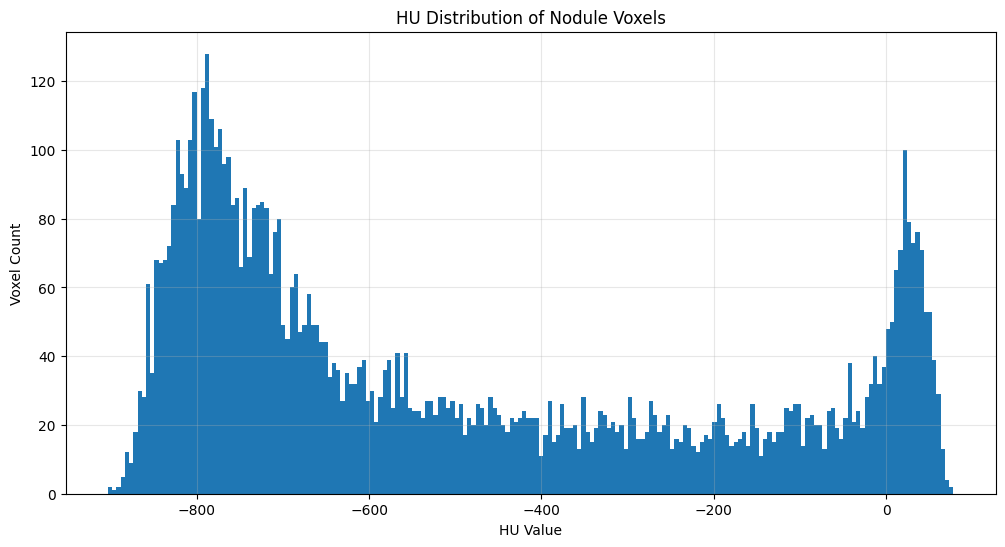

In [ ]:
import os
import json
import nibabel as nib
import numpy as np
import matplotlib.pyplot as plt

# --------------------------------------------------
# Paths
# --------------------------------------------------

volume_dir = "/home/chest_ct/code/data/data_volumes/dataset/train_fixed"
mask_dir = "/home/chest_ct/code/data/segmentations/segmentations"

json_path = "/home/chest_ct/code/data/rexgrounding-ct/dataset_2d.json"

# --------------------------------------------------
# Load selected cases
# --------------------------------------------------

with open(json_path, "r") as f:
    dataset = json.load(f)

selected_files = set(
    dataset.get("train", []) +
    dataset.get("test", [])
)

print(f"Selected CTs: {len(selected_files)}")

# --------------------------------------------------
# Collect HU values
# --------------------------------------------------

all_hu_values = []

processed = 0
missing_ct = []
missing_mask = []

for filename in sorted(selected_files):

    volume_path = os.path.join(volume_dir, filename)
    mask_path = os.path.join(mask_dir, filename)

    if not os.path.exists(volume_path):
        missing_ct.append(filename)
        continue

    if not os.path.exists(mask_path):
        missing_mask.append(filename)
        continue

    try:
        ct = nib.load(volume_path).get_fdata()
        gt_mask = nib.load(mask_path).get_fdata()

        # Multi-channel mask -> union of channels
        if gt_mask.ndim == 4:
            gt_mask = np.any(gt_mask > 0, axis=0)
        else:
            gt_mask = gt_mask > 0

        hu_values = ct[gt_mask]
        hu_values = hu_values[np.isfinite(hu_values)]

        if hu_values.size > 0:
            all_hu_values.append(hu_values)

        processed += 1

    except Exception as e:
        print(f"Error processing {filename}: {e}")

# --------------------------------------------------
# Summary
# --------------------------------------------------

print(f"\nProcessed: {processed}")
print(f"Missing CTs: {len(missing_ct)}")
print(f"Missing masks: {len(missing_mask)}")

if missing_ct:
    print("\nMissing CT files:")
    for x in missing_ct[:20]:
        print(" ", x)

if missing_mask:
    print("\nMissing mask files:")
    for x in missing_mask[:20]:
        print(" ", x)

# --------------------------------------------------
# HU statistics
# --------------------------------------------------

all_hu_values = np.concatenate(all_hu_values)

print("\n========== GLOBAL NODULE HU STATS ==========")
print("Voxel count:", all_hu_values.size)

for p in [1, 5, 25, 50, 75, 95, 99]:
    print(f"P{p:<2}:", float(np.percentile(all_hu_values, p)))

print("Min   :", float(np.min(all_hu_values)))
print("Max   :", float(np.max(all_hu_values)))
print("Mean  :", float(np.mean(all_hu_values)))
print("Median:", float(np.median(all_hu_values)))
print("Std   :", float(np.std(all_hu_values)))

# --------------------------------------------------
# Histogram
# --------------------------------------------------

plt.figure(figsize=(12, 6))
plt.hist(all_hu_values, bins=200)
plt.xlabel("HU Value")
plt.ylabel("Voxel Count")
plt.title("HU Distribution of Nodule Voxels")
plt.grid(alpha=0.3)
plt.show()

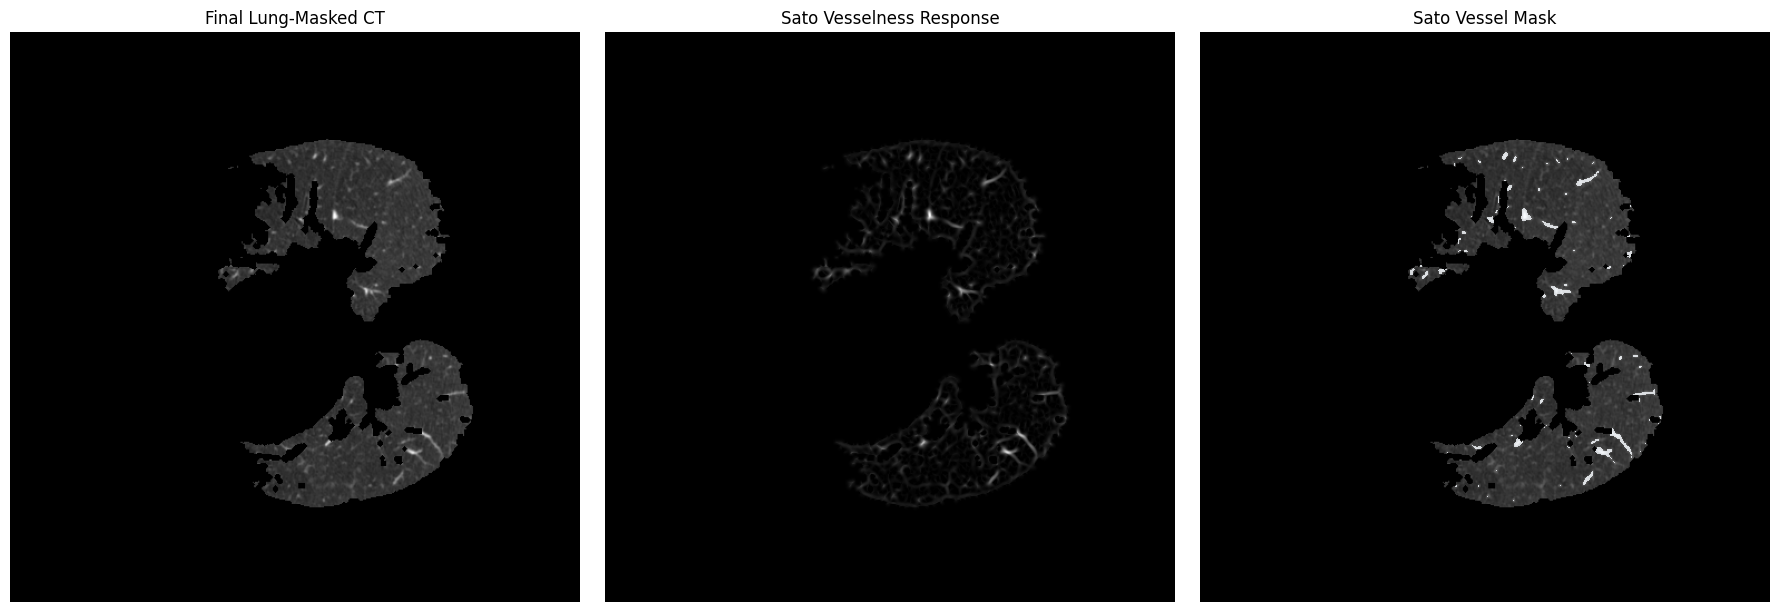

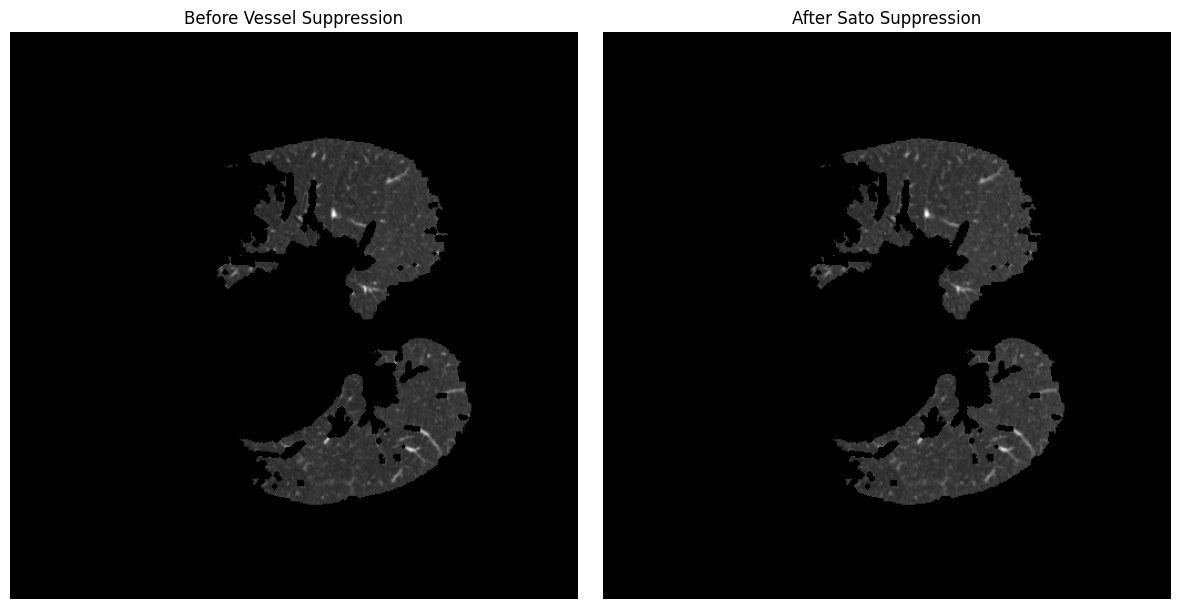

Slice index: 283

Sato vessel candidate pixel count on this slice:
Sato vessel pixels: 902


In [25]:
import numpy as np
import matplotlib.pyplot as plt

from scipy import ndimage
from skimage.filters import sato


# ============================================================
# Helper: normalize one CT slice inside lung
# ============================================================
def normalize_lung_slice(ct_slice, lung_slice, hu_min=-900, hu_max=200):
    """
    Clip one CT slice and normalize to [0, 1].
    Outside lung is set to 0.
    """
    ct_clip = np.clip(ct_slice, hu_min, hu_max)
    ct_norm = (ct_clip - hu_min) / (hu_max - hu_min)
    ct_norm[~lung_slice] = 0
    return ct_norm


# ============================================================
# Helper: suppress vessels on one slice only
# ============================================================
def suppress_vessels_from_slice(
    ct_slice,
    vesselness_slice,
    lung_slice,
    percentile=3
):
    """
    Suppress likely vessel pixels on one 2D slice.
    Vessel pixels are replaced by local median values.
    """
    values = vesselness_slice[lung_slice]

    if values.size == 0:
        return ct_slice.copy(), np.zeros_like(lung_slice, dtype=bool)

    threshold = np.percentile(values, percentile)

    vessel_mask = (vesselness_slice >= threshold) & lung_slice

    local_median = ndimage.median_filter(ct_slice, size=3)

    ct_suppressed = ct_slice.copy()
    ct_suppressed[vessel_mask] = local_median[vessel_mask]

    return ct_suppressed, vessel_mask


# ============================================================
# 1. Extract selected slice
# ============================================================
ct_slice = ct_lung_only[:, :, slice_idx]
lung_slice = lungs_final[:, :, slice_idx]


# ============================================================
# 2. Normalize selected slice for vessel filter
# ============================================================
ct_norm_slice = normalize_lung_slice(
    ct_slice=ct_slice,
    lung_slice=lung_slice,
    hu_min=-900,
    hu_max=200
)


# ============================================================
# 3. Apply Sato vessel filter on 2D slice
# ============================================================
sato_slice = sato(
    ct_norm_slice,
    sigmas=(1, 2),
    black_ridges=False
)


# ============================================================
# 4. Suppress vessel pixels using Sato response
# ============================================================
sato_removed_slice, sato_mask_slice = suppress_vessels_from_slice(
    ct_slice=ct_slice,
    vesselness_slice=sato_slice,
    lung_slice=lung_slice,
    percentile=97
)


# ============================================================
# 5. Visualize CT, Sato response, and vessel mask
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

axes[0].imshow(ct_slice, cmap="gray")
axes[0].set_title("Final Lung-Masked CT")
axes[0].axis("off")

axes[1].imshow(sato_slice, cmap="gray")
axes[1].set_title("Sato Vesselness Response")
axes[1].axis("off")

axes[2].imshow(ct_slice, cmap="gray")
axes[2].imshow(
    np.ma.masked_where(~sato_mask_slice, sato_mask_slice),
    cmap="Blues",
    alpha=0.8,
    interpolation="none"
)
axes[2].set_title("Sato Vessel Mask")
axes[2].axis("off")

plt.tight_layout()
plt.show()


# ============================================================
# 6. Visualize before/after vessel suppression
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

axes[0].imshow(ct_slice, cmap="gray")
axes[0].set_title("Before Vessel Suppression")
axes[0].axis("off")

axes[1].imshow(sato_removed_slice, cmap="gray")
axes[1].set_title("After Sato Suppression")
axes[1].axis("off")

plt.tight_layout()
plt.show()


# ============================================================
# 7. Print statistics for this slice
# ============================================================
print("Slice index:", slice_idx)
print("\nSato vessel candidate pixel count on this slice:")
print("Sato vessel pixels:", int(sato_mask_slice.sum()))

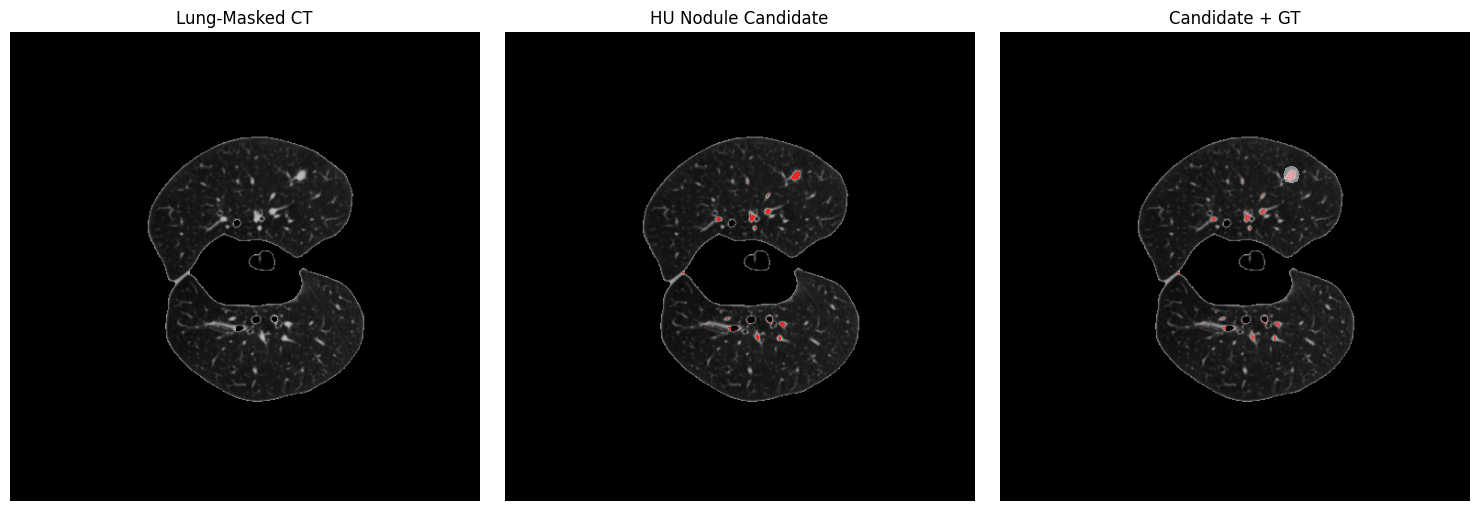

Candidate voxels: 76553


In [74]:
# ============================================================
# Step 2: Nodule HU threshold inside segmented lungs
# ============================================================

nodule_candidate = lungs_final & (
    (ct_lung_only >= -100) & (ct_lung_only <= 150)
)
#    ((ct >= -20) & (ct <= 50)) |
#    ((ct >= -850) & (ct <= -800))
nodule_candidate_slice = nodule_candidate[:, :, slice_idx]
ct_lung_only_slice = ct_lung_only[:, :, slice_idx]
gt_slice = gt_mask[:, :, slice_idx]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(ct_lung_only_slice, cmap="gray", vmin=-1000, vmax=400)
axes[0].set_title("Lung-Masked CT")
axes[0].axis("off")

axes[1].imshow(ct_lung_only_slice, cmap="gray", vmin=-1000, vmax=400)
axes[1].imshow(
    np.ma.masked_where(~nodule_candidate_slice, nodule_candidate_slice),
    cmap="autumn", alpha=0.8, interpolation="none"
)
axes[1].set_title("HU Nodule Candidate")
axes[1].axis("off")

axes[2].imshow(ct_lung_only_slice, cmap="gray", vmin=-1000, vmax=400)
axes[2].imshow(
    np.ma.masked_where(~nodule_candidate_slice, nodule_candidate_slice),
    cmap="autumn", alpha=0.6, interpolation="none"
)
axes[2].imshow(
    np.ma.masked_where(gt_slice <= 0, gt_slice),
    cmap="Blues", alpha=0.5, interpolation="none"
)
axes[2].set_title("Candidate + GT")
axes[2].axis("off")

plt.tight_layout()
plt.show()

print("Candidate voxels:", int(nodule_candidate.sum()))

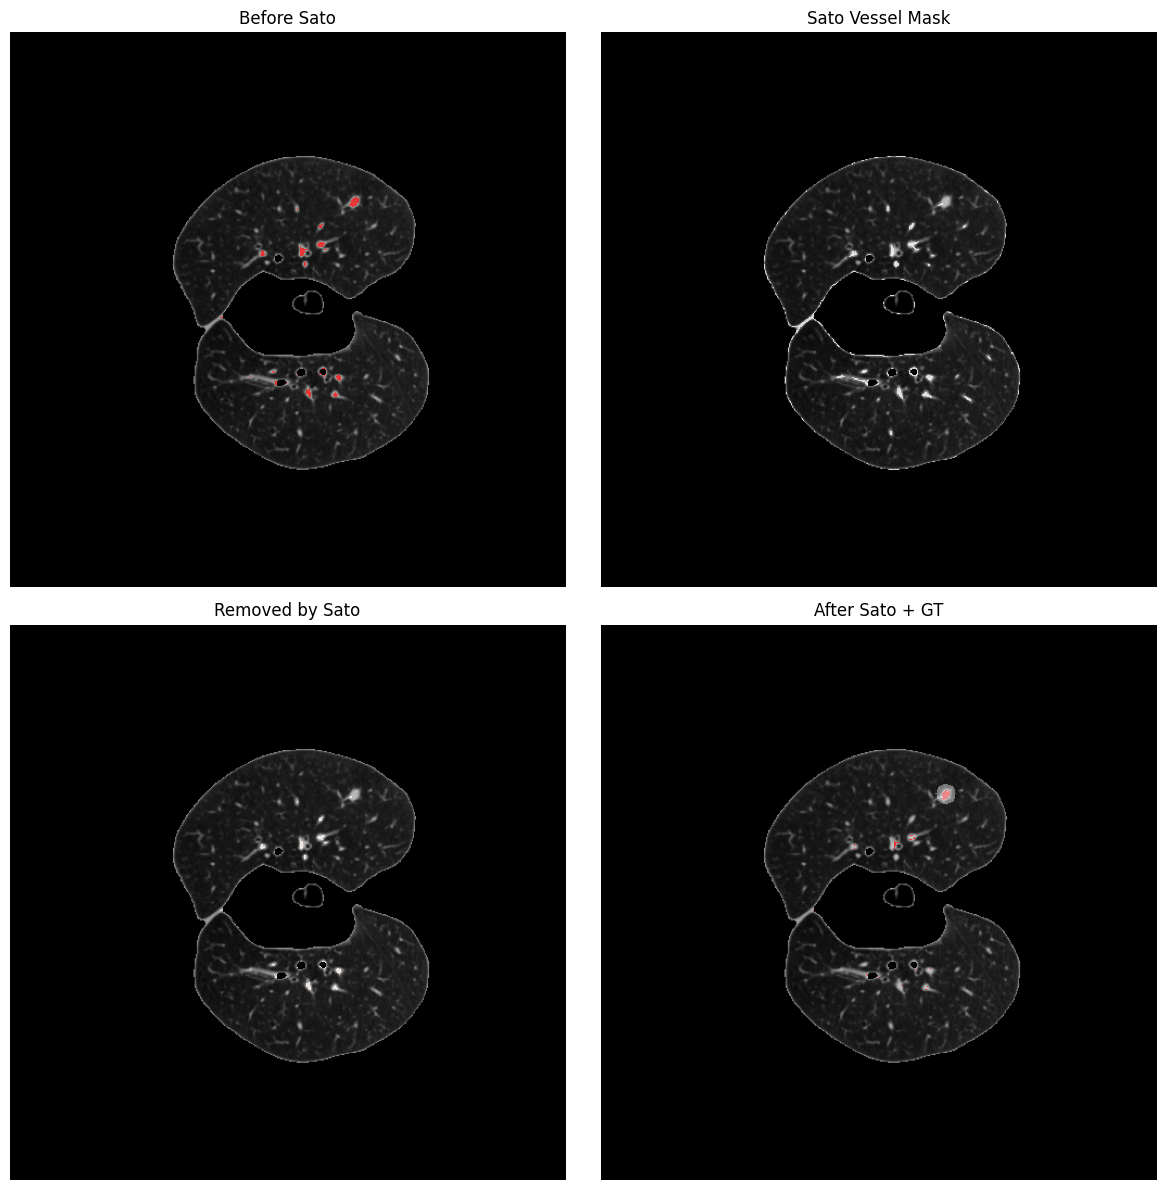

Before Sato : 225
Removed     : 150
After Sato  : 75


In [75]:
# ============================================================
# Sato vessel removal on selected slice
# ============================================================

from skimage.filters import sato

ct_slice = ct_lung_only[:, :, slice_idx]
lung_slice = lungs_final[:, :, slice_idx]
gt_slice = gt_mask[:, :, slice_idx] > 0
candidate_slice = nodule_candidate[:, :, slice_idx]

ct_norm_slice = np.clip(ct_slice, -900, 200)
ct_norm_slice = (ct_norm_slice + 900) / 1100
ct_norm_slice[~lung_slice] = 0

vesselness_slice = sato(ct_norm_slice, sigmas=(1, 2), black_ridges=False)

vessel_slice = (
    vesselness_slice >= np.percentile(vesselness_slice[lung_slice], 98.5)
) & lung_slice

candidate_after_sato = candidate_slice & ~vessel_slice
removed_by_sato = candidate_slice & vessel_slice

fig, axes = plt.subplots(2, 2, figsize=(12, 12))
axes = axes.ravel()

axes[0].imshow(ct_slice, cmap="gray", vmin=-1000, vmax=400)
axes[0].imshow(np.ma.masked_where(~candidate_slice, candidate_slice),
               cmap="autumn", alpha=0.7, interpolation="none")
axes[0].set_title("Before Sato")
axes[0].axis("off")

axes[1].imshow(ct_slice, cmap="gray", vmin=-1000, vmax=400)
axes[1].imshow(np.ma.masked_where(~vessel_slice, vessel_slice),
               cmap="Blues", alpha=0.7, interpolation="none")
axes[1].set_title("Sato Vessel Mask")
axes[1].axis("off")

axes[2].imshow(ct_slice, cmap="gray", vmin=-1000, vmax=400)
axes[2].imshow(np.ma.masked_where(~removed_by_sato, removed_by_sato),
               cmap="Reds", alpha=0.8, interpolation="none")
axes[2].set_title("Removed by Sato")
axes[2].axis("off")

axes[3].imshow(ct_slice, cmap="gray", vmin=-1000, vmax=400)
axes[3].imshow(np.ma.masked_where(~candidate_after_sato, candidate_after_sato),
               cmap="autumn", alpha=0.7, interpolation="none")
axes[3].imshow(np.ma.masked_where(~gt_slice, gt_slice),
               cmap="Blues", alpha=0.4, interpolation="none")
axes[3].set_title("After Sato + GT")
axes[3].axis("off")

plt.tight_layout()
plt.show()

print("Before Sato :", int(candidate_slice.sum()))
print("Removed     :", int(removed_by_sato.sum()))
print("After Sato  :", int(candidate_after_sato.sum()))

In [76]:
# ============================================================
# Step 4: Validate Sato vessel removal on selected slice
# ============================================================

candidate_slice = nodule_candidate[:, :, slice_idx]
gt_slice_bool = gt_mask[:, :, slice_idx] > 0

candidate_after_sato = candidate_slice & ~vessel_slice
removed_by_sato = candidate_slice & vessel_slice

gt_before = np.logical_and(candidate_slice, gt_slice_bool).sum()
gt_after = np.logical_and(candidate_after_sato, gt_slice_bool).sum()

removed_total = removed_by_sato.sum()
removed_gt = np.logical_and(removed_by_sato, gt_slice_bool).sum()
removed_non_gt = removed_total - removed_gt

print("Candidate pixels before:", int(candidate_slice.sum()))
print("Candidate pixels after :", int(candidate_after_sato.sum()))
print("Removed pixels         :", int(removed_total))

print("\nGT overlap before:", int(gt_before))
print("GT overlap after :", int(gt_after))

print("\nRemoved GT pixels    :", int(removed_gt))
print("Removed non-GT pixels:", int(removed_non_gt))

print("\nGT loss percentage:",
      float(removed_gt / (gt_slice_bool.sum() + 1e-8) * 100), "%")

Candidate pixels before: 225
Candidate pixels after : 75
Removed pixels         : 150

GT overlap before: 50
GT overlap after : 44

Removed GT pixels    : 6
Removed non-GT pixels: 144

GT loss percentage: 2.230483271292547 %


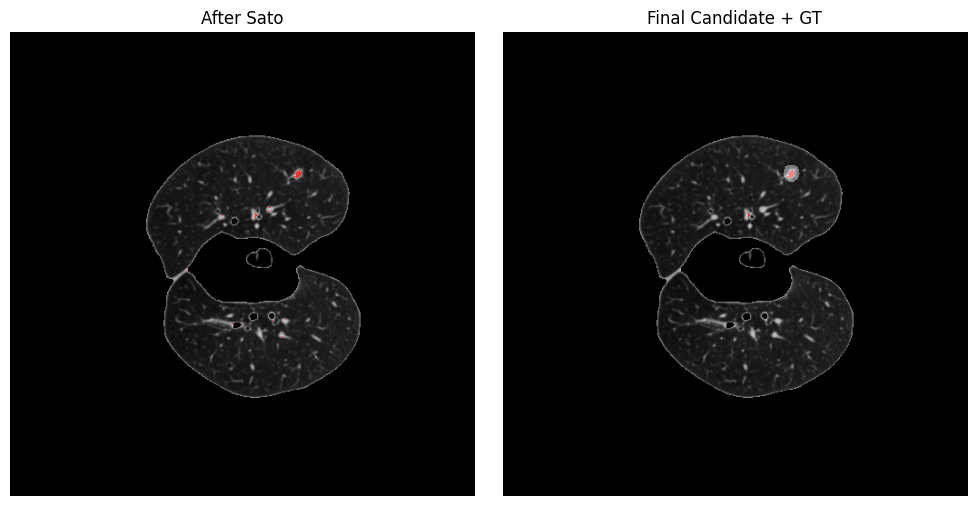

Components before filtering: 17
Pixels after filtering: 55


In [77]:
# ============================================================
# Step 6: Connected component filtering
# ============================================================

from skimage.measure import label, regionprops

labeled = label(candidate_after_sato, connectivity=1)

final_candidate = np.zeros_like(candidate_after_sato, dtype=bool)

MIN_PIXELS = 5
MAX_PIXELS = 500

for region in regionprops(labeled):
    if MIN_PIXELS <= region.area <= MAX_PIXELS:
        final_candidate[labeled == region.label] = True

fig, axes = plt.subplots(1, 2, figsize=(10, 5))

axes[0].imshow(ct_slice, cmap="gray", vmin=-1000, vmax=400)
axes[0].imshow(np.ma.masked_where(~candidate_after_sato, candidate_after_sato),
               cmap="autumn", alpha=0.7, interpolation="none")
axes[0].set_title("After Sato")
axes[0].axis("off")

axes[1].imshow(ct_slice, cmap="gray", vmin=-1000, vmax=400)
axes[1].imshow(np.ma.masked_where(~final_candidate, final_candidate),
               cmap="autumn", alpha=0.7, interpolation="none")
axes[1].imshow(np.ma.masked_where(~gt_slice, gt_slice),
               cmap="Blues", alpha=0.4, interpolation="none")
axes[1].set_title("Final Candidate + GT")
axes[1].axis("off")

plt.tight_layout()
plt.show()

print("Components before filtering:", int(labeled.max()))
print("Pixels after filtering:", int(final_candidate.sum()))

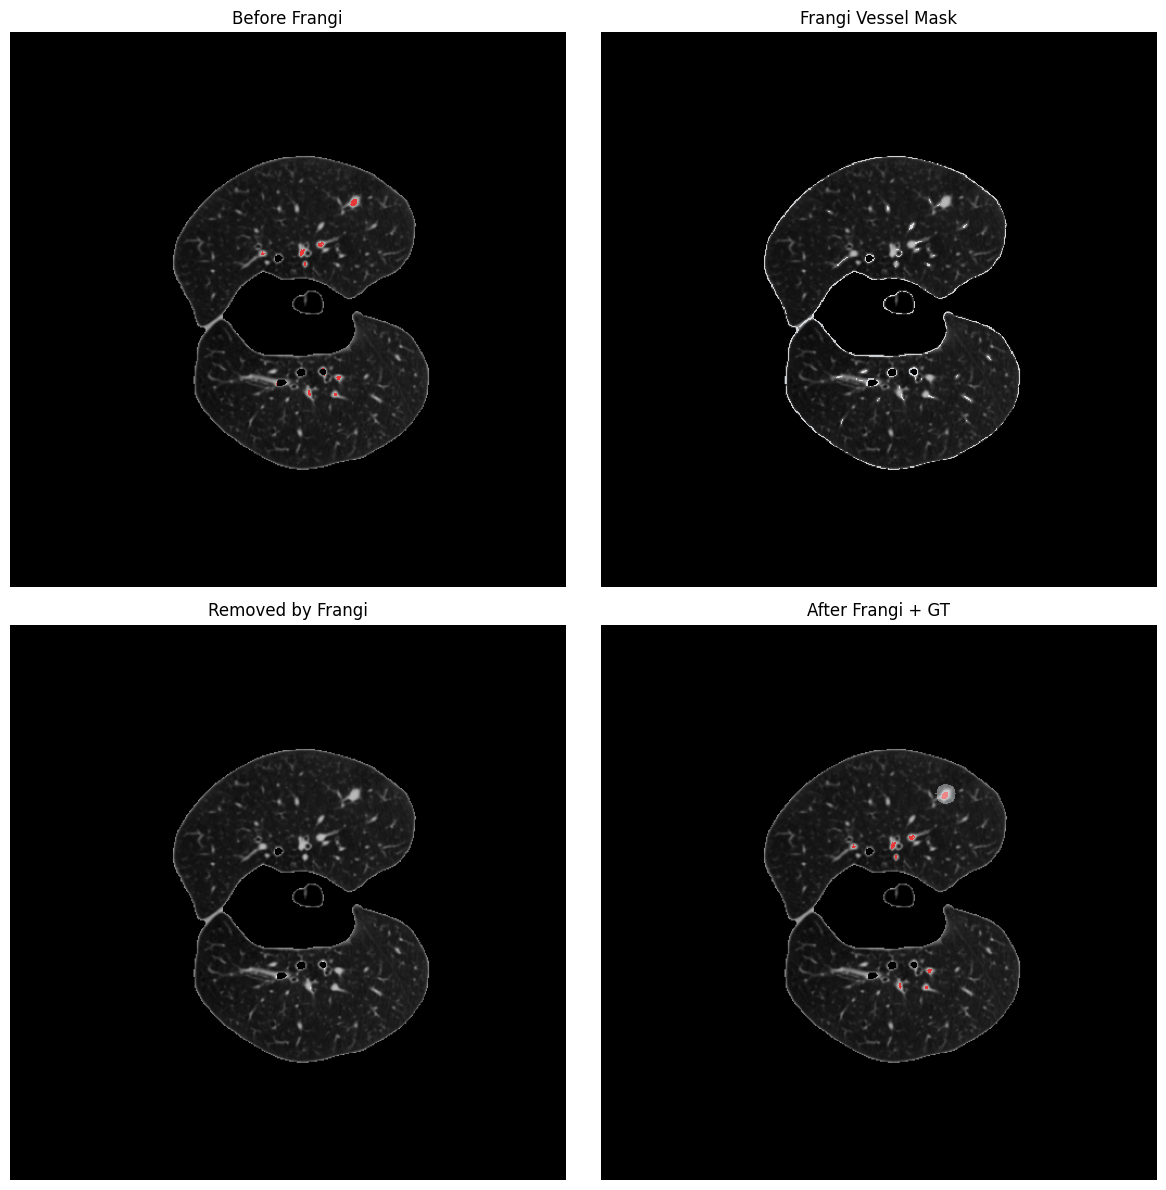

Before Frangi : 120
Removed       : 7
After Frangi  : 113


In [41]:
# ============================================================
# Frangi vessel removal on selected slice
# ============================================================

from skimage.filters import frangi

frangi_vesselness_slice = frangi(ct_norm_slice, sigmas=(1, 2), black_ridges=False)

frangi_vessel_slice = (
    frangi_vesselness_slice >= np.percentile(frangi_vesselness_slice[lung_slice], 97)
) & lung_slice

candidate_after_frangi = candidate_slice & ~frangi_vessel_slice
removed_by_frangi = candidate_slice & frangi_vessel_slice

fig, axes = plt.subplots(2, 2, figsize=(12, 12))
axes = axes.ravel()

axes[0].imshow(ct_slice, cmap="gray", vmin=-1000, vmax=400)
axes[0].imshow(np.ma.masked_where(~candidate_slice, candidate_slice),
               cmap="autumn", alpha=0.7, interpolation="none")
axes[0].set_title("Before Frangi")
axes[0].axis("off")

axes[1].imshow(ct_slice, cmap="gray", vmin=-1000, vmax=400)
axes[1].imshow(np.ma.masked_where(~frangi_vessel_slice, frangi_vessel_slice),
               cmap="Blues", alpha=0.7, interpolation="none")
axes[1].set_title("Frangi Vessel Mask")
axes[1].axis("off")

axes[2].imshow(ct_slice, cmap="gray", vmin=-1000, vmax=400)
axes[2].imshow(np.ma.masked_where(~removed_by_frangi, removed_by_frangi),
               cmap="Reds", alpha=0.8, interpolation="none")
axes[2].set_title("Removed by Frangi")
axes[2].axis("off")

axes[3].imshow(ct_slice, cmap="gray", vmin=-1000, vmax=400)
axes[3].imshow(np.ma.masked_where(~candidate_after_frangi, candidate_after_frangi),
               cmap="autumn", alpha=0.7, interpolation="none")
axes[3].imshow(np.ma.masked_where(~gt_slice, gt_slice),
               cmap="Blues", alpha=0.4, interpolation="none")
axes[3].set_title("After Frangi + GT")
axes[3].axis("off")

plt.tight_layout()
plt.show()

print("Before Frangi :", int(candidate_slice.sum()))
print("Removed       :", int(removed_by_frangi.sum()))
print("After Frangi  :", int(candidate_after_frangi.sum()))

In [39]:
# ============================================================
# Evaluate Frangi vessel removal against GT
# ============================================================

frangi_removed_gt = np.logical_and(removed_by_frangi, gt_slice).sum()
frangi_removed_non_gt = removed_by_frangi.sum() - frangi_removed_gt

frangi_gt_before = np.logical_and(candidate_slice, gt_slice).sum()
frangi_gt_after = np.logical_and(candidate_after_frangi, gt_slice).sum()

print("GT overlap before Frangi:", int(frangi_gt_before))
print("GT overlap after Frangi :", int(frangi_gt_after))

print("Removed GT pixels       :", int(frangi_removed_gt))
print("Removed non-GT pixels   :", int(frangi_removed_non_gt))

print("GT loss percentage      :",
      float(frangi_removed_gt / (gt_slice.sum() + 1e-8) * 100), "%")

GT overlap before Frangi: 31
GT overlap after Frangi : 0
Removed GT pixels       : 31
Removed non-GT pixels   : 89
GT loss percentage      : 11.524163568344827 %


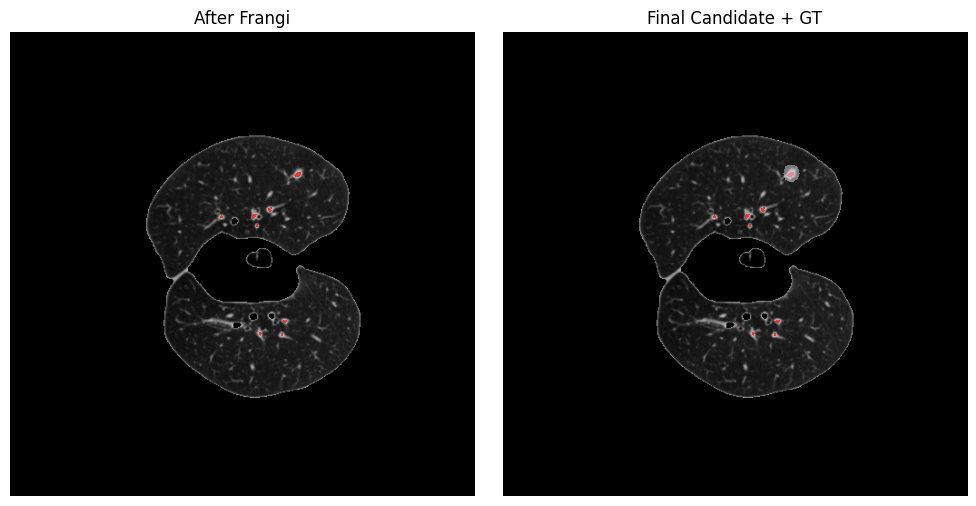

Components before filtering: 8
Pixels after filtering: 113


In [58]:
# ============================================================
# Step 6: Connected component filtering
# ============================================================

from skimage.measure import label, regionprops

labeled = label(candidate_after_frangi, connectivity=1)

final_candidate = np.zeros_like(candidate_after_frangi, dtype=bool)

MIN_PIXELS = 5
MAX_PIXELS = 500

for region in regionprops(labeled):
    if MIN_PIXELS <= region.area <= MAX_PIXELS:
        final_candidate[labeled == region.label] = True

fig, axes = plt.subplots(1, 2, figsize=(10, 5))

axes[0].imshow(ct_slice, cmap="gray", vmin=-1000, vmax=400)
axes[0].imshow(np.ma.masked_where(~candidate_after_frangi, candidate_after_frangi),
               cmap="autumn", alpha=0.7, interpolation="none")
axes[0].set_title("After Frangi")
axes[0].axis("off")

axes[1].imshow(ct_slice, cmap="gray", vmin=-1000, vmax=400)
axes[1].imshow(np.ma.masked_where(~final_candidate, final_candidate),
               cmap="autumn", alpha=0.7, interpolation="none")
axes[1].imshow(np.ma.masked_where(~gt_slice, gt_slice),
               cmap="Blues", alpha=0.4, interpolation="none")
axes[1].set_title("Final Candidate + GT")
axes[1].axis("off")

plt.tight_layout()
plt.show()

print("Components before filtering:", int(labeled.max()))
print("Pixels after filtering:", int(final_candidate.sum()))

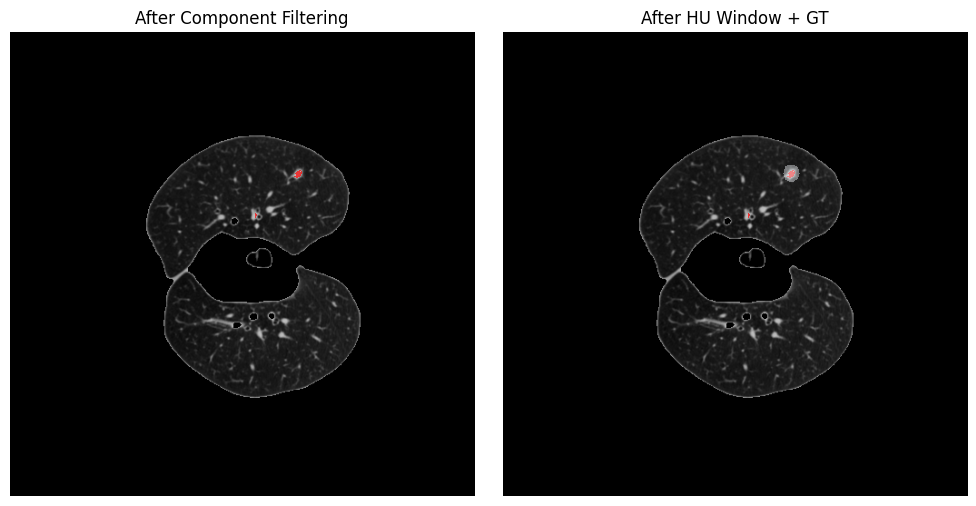

Before HU windowing: 55
After HU windowing : 55


In [78]:
# ============================================================
# HU windowing after connected component filtering - selected slice
# ============================================================

final_hu_windowed = final_candidate & (
    (ct_slice >= -100) & (ct_slice <= 150)
)

fig, axes = plt.subplots(1, 2, figsize=(10, 5))

axes[0].imshow(ct_slice, cmap="gray", vmin=-1000, vmax=400)
axes[0].imshow(np.ma.masked_where(~final_candidate, final_candidate),
               cmap="autumn", alpha=0.7, interpolation="none")
axes[0].set_title("After Component Filtering")
axes[0].axis("off")

axes[1].imshow(ct_slice, cmap="gray", vmin=-1000, vmax=400)
axes[1].imshow(np.ma.masked_where(~final_hu_windowed, final_hu_windowed),
               cmap="autumn", alpha=0.7, interpolation="none")
axes[1].imshow(np.ma.masked_where(~gt_slice, gt_slice),
               cmap="Blues", alpha=0.4, interpolation="none")
axes[1].set_title("After HU Window + GT")
axes[1].axis("off")

plt.tight_layout()
plt.show()

print("Before HU windowing:", int(final_candidate.sum()))
print("After HU windowing :", int(final_hu_windowed.sum()))

In [79]:
# ============================================================
# Evaluation metrics for final 2D prediction
# ============================================================

pred = final_hu_windowed > 0
gt = gt_slice > 0

tp = np.logical_and(pred, gt).sum()
fp = np.logical_and(pred, ~gt).sum()
fn = np.logical_and(~pred, gt).sum()
tn = np.logical_and(~pred, ~gt).sum()

dice = (2 * tp) / (2 * tp + fp + fn + 1e-8)
iou = tp / (tp + fp + fn + 1e-8)
precision = tp / (tp + fp + 1e-8)
recall = tp / (tp + fn + 1e-8)
specificity = tn / (tn + fp + 1e-8)

print("Dice       :", float(dice))
print("IoU        :", float(iou))
print("Precision  :", float(precision))
print("Recall     :", float(recall))
print("Specificity:", float(specificity))

print("\nTP:", int(tp))
print("FP:", int(fp))
print("FN:", int(fn))
print("TN:", int(tn))

Dice       : 0.2716049382632221
IoU        : 0.1571428571372449
Precision  : 0.7999999998545454
Recall     : 0.1635687732281201
Specificity: 0.999957995226692

TP: 44
FP: 11
FN: 225
TN: 261864


In [ ]:
# ============================================================
# Whole-volume nodule pipeline after lung segmentation
# Windowing -> slice-wise Sato -> vessel removal -> components -> evaluation
# ============================================================

from skimage.filters import sato
from skimage.measure import label, regionprops
import numpy as np

LOW_HU = -150
HIGH_HU = 200
SATO_PERCENTILE = 98.5
MIN_VOXELS = 20
MAX_VOXELS = 5000

# 1. HU windowing inside segmented lungs
nodule_candidate_3d = lungs_final & (
    (ct_lung_only >= LOW_HU) & (ct_lung_only <= HIGH_HU)
)

# 2. Sato vessel detection slice-by-slice
vessel_mask_3d = np.zeros_like(lungs_final, dtype=bool)

for k in range(ct_lung_only.shape[2]):
    lung_slice = lungs_final[:, :, k]

    if lung_slice.sum() == 0:
        continue

    ct_slice = ct_lung_only[:, :, k]

    ct_norm = np.clip(ct_slice, -900, 200)
    ct_norm = (ct_norm + 900) / 1100
    ct_norm[~lung_slice] = 0

    vesselness = sato(ct_norm, sigmas=(1, 2), black_ridges=False)

    vessel_mask_3d[:, :, k] = (
        vesselness >= np.percentile(vesselness[lung_slice], SATO_PERCENTILE)
    ) & lung_slice

# 3. Remove vessel-like pixels
candidate_no_vessels_3d = nodule_candidate_3d & ~vessel_mask_3d

# 4. Connected component filtering
labeled = label(candidate_no_vessels_3d, connectivity=1)
final_candidate_3d = np.zeros_like(candidate_no_vessels_3d, dtype=bool)

for region in regionprops(labeled):
    if MIN_VOXELS <= region.area <= MAX_VOXELS:
        final_candidate_3d[labeled == region.label] = True

# 5. Evaluation against GT
gt_3d = gt_mask > 0
pred_3d = final_candidate_3d > 0

tp = np.logical_and(pred_3d, gt_3d).sum()
fp = np.logical_and(pred_3d, ~gt_3d).sum()
fn = np.logical_and(~pred_3d, gt_3d).sum()
tn = np.logical_and(~pred_3d, ~gt_3d).sum()

dice = (2 * tp) / (2 * tp + fp + fn + 1e-8)
iou = tp / (tp + fp + fn + 1e-8)
precision = tp / (tp + fp + 1e-8)
recall = tp / (tp + fn + 1e-8)
specificity = tn / (tn + fp + 1e-8)

print("Dice       :", float(dice))
print("IoU        :", float(iou))
print("Precision  :", float(precision))
print("Recall     :", float(recall))
print("Specificity:", float(specificity))

print("\nTP:", int(tp))
print("FP:", int(fp))
print("FN:", int(fn))
print("TN:", int(tn))